<a href="https://colab.research.google.com/github/DivyaMeenaSundaram/Probability-and-Statistics/blob/main/3_Exponential_Gamma_Weibull_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Import the file upload tool provided by Google Colab
from google.colab import files

# Open the file selection window
uploaded = files.upload()

Saving system_response_times.xlsx to system_response_times.xlsx


In [2]:
import pandas as pd

# Read the uploaded Excel file
data = pd.read_excel("system_response_times.xlsx")

# Display the dataset
data

,Request_ID,Request_Type,Server,Response_Time_sec
0,1,Product,Server_C,0.59
1,2,Search,Server_B,0.42
2,3,Login,Server_B,0.64
3,4,Search,Server_B,1.04
4,5,Profile,Server_A,0.40
...,...,...,...,...
95,96,Search,Server_B,0.20
96,97,Profile,Server_B,0.53
97,98,Search,Server_B,0.52
98,99,Profile,Server_B,0.45


In [4]:
# Calculate some basic response-time statistics

average_time = data["Response_Time_sec"].mean()
minimum_time = data["Response_Time_sec"].min()
maximum_time = data["Response_Time_sec"].max()

print(f"Average response time : {average_time:.2f} seconds")
print(f"Minimum response time : {minimum_time:.2f} seconds")
print(f"Maximum response time : {maximum_time:.2f} seconds")

Average response time : 0.48 seconds
Minimum response time : 0.12 seconds
Maximum response time : 1.25 seconds


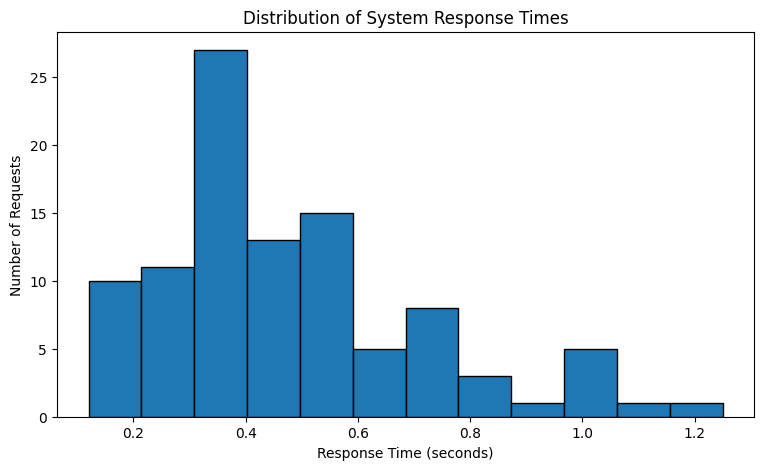

In [5]:
import matplotlib.pyplot as plt

# Create a histogram of response times

plt.figure(figsize=(9, 5))

plt.hist(
    data["Response_Time_sec"],
    bins=12,
    edgecolor="black"
)

plt.xlabel("Response Time (seconds)")
plt.ylabel("Number of Requests")
plt.title("Distribution of System Response Times")

plt.show()

Where are most of the requests concentrated?

Are there a few requests that are much slower?

This leads naturally to: Right-skewed data

In [6]:
# Define the response-time threshold

threshold = 1.0

# Select requests that took more than 1 second
slow_requests = data[
    data["Response_Time_sec"] > threshold
]

print("Number of slow requests:", len(slow_requests))

Number of slow requests: 7


In [7]:
# Calculate the percentage of requests
# that took more than 1 second

slow_percentage = (
    len(slow_requests) / len(data)
) * 100

print(
    f"Percentage of slow requests: "
    f"{slow_percentage:.2f}%"
)

Percentage of slow requests: 7.00%


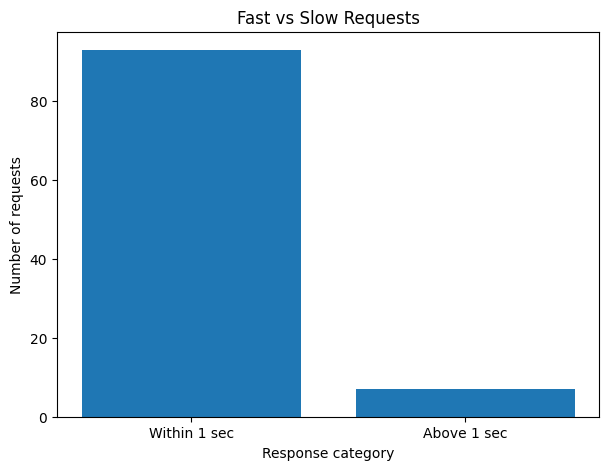

In [8]:
# Count requests that are within the threshold
# and requests that exceed the threshold

fast_requests = len(data) - len(slow_requests)

labels = ["Within 1 sec", "Above 1 sec"]
values = [fast_requests, len(slow_requests)]

plt.figure(figsize=(7, 5))

plt.bar(labels, values)

plt.xlabel("Response category")
plt.ylabel("Number of requests")
plt.title("Fast vs Slow Requests")

plt.show()

We have observed response times. But instead of simply describing the past 100 requests, can we build a probability model that helps us understand future requests?

This is where the probability distribution comes in.

The response time is continuous,
is positive, and
is generally right-skewed

So distributions such as Exponential /
Gamma /
Weibull can be considered as models.

The Exponential distribution is commonly used as a simple model for positive waiting-time type quantities.

In [9]:
from scipy.stats import expon

# Calculate the average response time
mean_response_time = data["Response_Time_sec"].mean()

print(
    f"Average response time: "
    f"{mean_response_time:.2f} seconds"
)

Average response time: 0.48 seconds


According to the Exponential model, what is the probability that a response takes more than 1 second?

In [10]:
# Calculate the probability that response time
# is greater than 1 second

probability_slow = 1 - expon.cdf(
    1.0,
    scale=mean_response_time
)

print(
    f"Probability of response time > 1 second: "
    f"{probability_slow * 100:.2f}%"
)

Probability of response time > 1 second: 12.40%


Now we can generate an Exponential distribution based on our observed average.

In [11]:
import numpy as np

# Generate 1,000 response times using
# the Exponential model

simulated_times = np.random.exponential(
    scale=mean_response_time,
    size=1000
)

print(simulated_times[:10])

[0.06455209 0.05016998 0.12273523 0.14444883 1.34925654 0.06572158
 0.36600251 0.89688306 0.7659729  0.36570693]


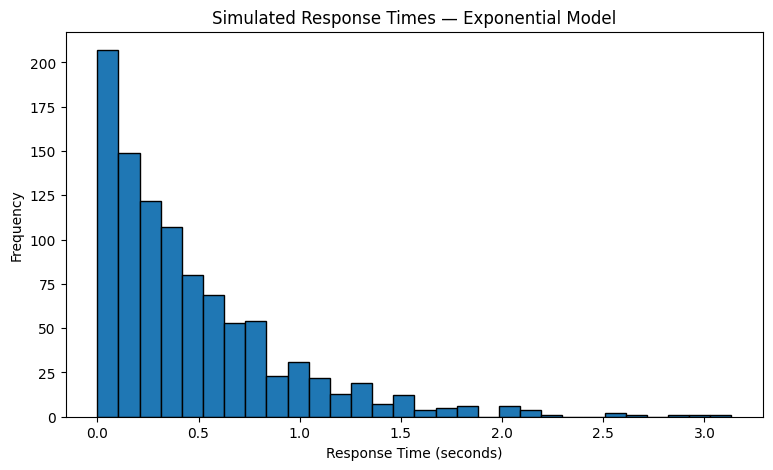

In [12]:
# Plot the simulated response times

plt.figure(figsize=(9, 5))

plt.hist(
    simulated_times,
    bins=30,
    edgecolor="black"
)

plt.xlabel("Response Time (seconds)")
plt.ylabel("Frequency")
plt.title("Simulated Response Times — Exponential Model")

plt.show()

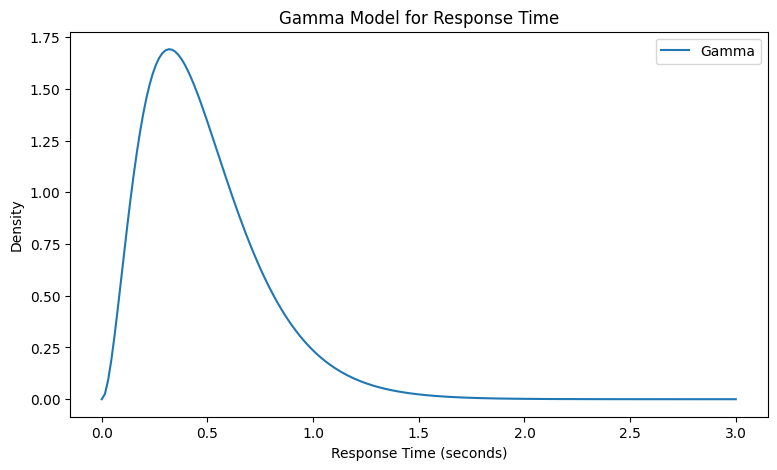

In [13]:
from scipy.stats import gamma

# Create response-time values for the x-axis
x = np.linspace(0, 3, 200)

# Create a Gamma probability-density curve
gamma_curve = gamma.pdf(
    x,
    a=3,
    scale=0.16
)

plt.figure(figsize=(9, 5))

plt.plot(
    x,
    gamma_curve,
    label="Gamma"
)

plt.xlabel("Response Time (seconds)")
plt.ylabel("Density")
plt.title("Gamma Model for Response Time")

plt.legend()

plt.show()

Gamma gives us another possible model for positive, right-skewed response times.

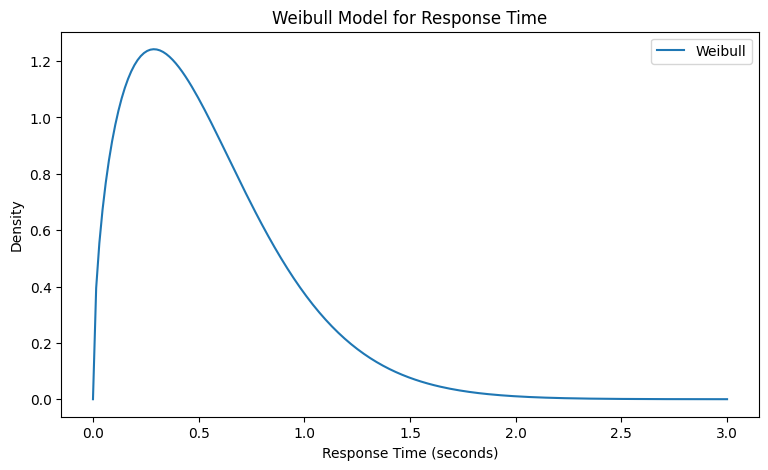

In [14]:
from scipy.stats import weibull_min

# Create a Weibull probability-density curve

weibull_curve = weibull_min.pdf(
    x,
    1.5,
    scale=0.6
)

plt.figure(figsize=(9, 5))

plt.plot(
    x,
    weibull_curve,
    label="Weibull"
)

plt.xlabel("Response Time (seconds)")
plt.ylabel("Density")
plt.title("Weibull Model for Response Time")

plt.legend()

plt.show()

Weibull is another flexible model for positive continuous data.

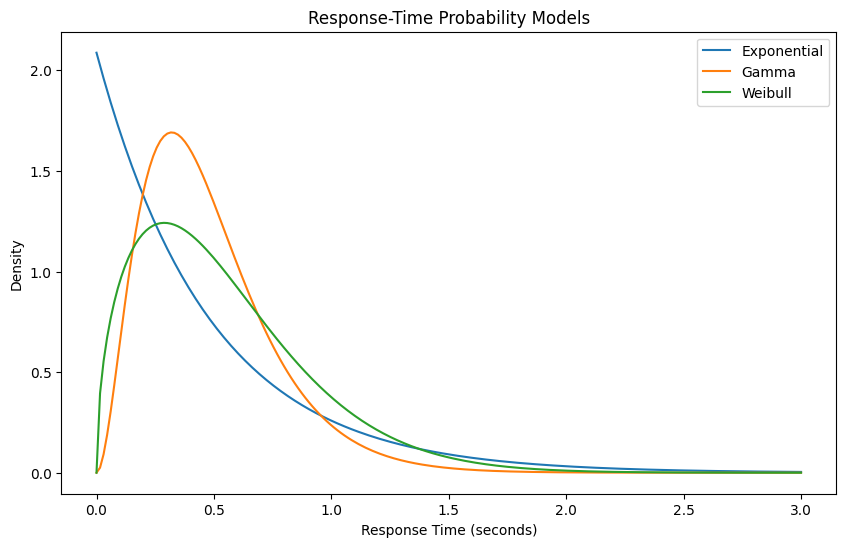

In [15]:
from scipy.stats import expon, gamma, weibull_min

# Create x-values for the distribution curves
x = np.linspace(0, 3, 200)

# Exponential model
exponential_curve = expon.pdf(
    x,
    scale=mean_response_time
)

# Gamma model
gamma_curve = gamma.pdf(
    x,
    a=3,
    scale=0.16
)

# Weibull model
weibull_curve = weibull_min.pdf(
    x,
    1.5,
    scale=0.6
)

# Plot all three models
plt.figure(figsize=(10, 6))

plt.plot(
    x,
    exponential_curve,
    label="Exponential"
)

plt.plot(
    x,
    gamma_curve,
    label="Gamma"
)

plt.plot(
    x,
    weibull_curve,
    label="Weibull"
)

plt.xlabel("Response Time (seconds)")
plt.ylabel("Density")
plt.title("Response-Time Probability Models")

plt.legend()

plt.show()